In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle as pkl

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import partial_dependence

In [68]:
X_train_encoded

,encoder1__TP_COR_RACA_True,encoder1__TP_FAIXA_ETARIA_0,encoder1__TP_FAIXA_ETARIA_1,encoder1__TP_FAIXA_ETARIA_2,encoder1__TP_FAIXA_ETARIA_3,encoder1__TP_FAIXA_ETARIA_4,encoder1__TP_FAIXA_ETARIA_5,encoder2__TP_SEXO_M,encoder2__TP_ESTADO_CIVIL_infrequent_sklearn,encoder2__TP_ST_CONCLUSAO_1,...,encoder2__Q022_infrequent_sklearn,encoder2__Q023_A,encoder2__Q023_B,encoder2__Q023_infrequent_sklearn,encoder2__Q024_A,encoder2__Q024_B,encoder2__Q024_infrequent_sklearn,encoder2__Q025_A,encoder2__Q025_B,encoder2__Q025_infrequent_sklearn
636846,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3241716,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3310188,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2922210,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2765433,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3146551,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2248725,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2498088,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5173243,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [45]:
# first create the "clean pool" of applicants
df = pd.read_csv("data/MICRODADOS_ENEM_2020.csv", encoding="cp860", sep=";")

# drop rows with NU_NOTA_LC
df = df.dropna(subset=["NU_NOTA_LC"])

df = df.sample(10_000, random_state=42)
# I will consider the score in portuguese test
df["target"] = df["NU_NOTA_LC"]
df["TP_DEPENDENCIA_ADM_ESC"] = df["TP_DEPENDENCIA_ADM_ESC"].fillna(-1)

# put everyone above 50 years to the class of 50 years
df["TP_FAIXA_ETARIA"] = df["TP_FAIXA_ETARIA"].apply(lambda x : min(x, 6))

In [46]:
columns_to_drop = [
    "NU_INSCRICAO",
    "NU_ANO",
    "CO_MUNICIPIO_ESC",
    "NO_MUNICIPIO_ESC",
    "CO_UF_ESC",
    "CO_MUNICIPIO_PROVA",
    'NO_MUNICIPIO_PROVA',
    'CO_UF_PROVA',
    'SG_UF_PROVA',
    'TP_PRESENCA_CN',
    'TP_PRESENCA_CH',
    'TP_PRESENCA_LC',
    'TP_PRESENCA_MT',
    'CO_PROVA_CN',
    'CO_PROVA_CH',
    'CO_PROVA_LC',
    'CO_PROVA_MT',
    'NU_NOTA_CN',
    'NU_NOTA_CH',
    'NU_NOTA_LC',
    'NU_NOTA_MT',
    'TX_RESPOSTAS_CN',
    'TX_RESPOSTAS_CH',
    'TX_RESPOSTAS_LC',
    'TX_RESPOSTAS_MT',
    'TX_GABARITO_CN',
    'TX_GABARITO_CH',
    'TX_GABARITO_LC',
    'TX_GABARITO_MT',
    'TP_STATUS_REDACAO',
    'NU_NOTA_COMP1',
    'NU_NOTA_COMP2',
    'NU_NOTA_COMP3',
    'NU_NOTA_COMP4',
    'NU_NOTA_COMP5',
    'NU_NOTA_REDACAO',
    "TP_NACIONALIDADE",
    "SG_UF_ESC",
]

In [47]:
df = df.drop(columns = columns_to_drop)
for col in ["TP_LOCALIZACAO_ESC", "TP_SIT_FUNC_ESC", "TP_ENSINO"]:
        df[col] = df[col].fillna("Unknown")

df["TP_FAIXA_ETARIA"] = df["TP_FAIXA_ETARIA"] - 1

# convert all columns to str
df["TP_COR_RACA"] = df["TP_COR_RACA"].apply(lambda x : x == 1)
for col in df.columns:
    df[col] = df[col].apply(str)
df["target"] = df["target"].astype(float)

# make first column be "TP_COR_RACA" followed by "TP_FAIXA_ETARIA"
remaining_columns = [col for col in df.columns if col not in ["TP_COR_RACA", "TP_FAIXA_ETARIA"]]
df = df[["TP_COR_RACA", "TP_FAIXA_ETARIA"] + remaining_columns]
df["target"] = df["target"].apply(lambda x : 1 if x > 500 else 0)

In [50]:
X = df.drop(columns=["target"])
y = df["target"]

print("Positive rate:", np.mean(y))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
transformer = ColumnTransformer(
    transformers=[
        ("encoder1", OneHotEncoder(sparse_output=False, drop = "if_binary"), ["TP_COR_RACA", "TP_FAIXA_ETARIA"]),
        ("encoder2", OneHotEncoder(sparse_output=False, handle_unknown="infrequent_if_exist", drop="if_binary", min_frequency=0.1),
         [col for col in X.columns if col not in ["TP_FAIXA_ETARIA", "TP_COR_RACA"]]),
    ],
    remainder="passthrough"
)
transformer.set_output(transform="pandas")  # Ensure the output is a DataFrame
pipeline = Pipeline(
    steps = [("t1", transformer)]
)

X_train_encoded = pipeline.fit_transform(X_train)
X_test_encoded = pipeline.transform(X_test)

Positive rate: 0.6602


/work/giovani.valdrighi/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [15, 26] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [51]:
model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
model.fit(X_train_encoded.values, y_train)

y_pred = model.predict(X_test_encoded)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print(f"Positive rate in predictions: {np.mean(y_pred):.2f}")

Accuracy: 0.69
Positive rate in predictions: 0.54


/work/giovani.valdrighi/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [52]:
Z = X_test_encoded["encoder1__TP_COR_RACA_True"].values
Z = Z.astype(int)  # Ensure Z is of integer type

for i in range(2):
    print(f"Group {i} probability: {np.mean(Z == i):.2f}")
    print(f"Group {i} accuracy: {accuracy_score(y_test[Z == i], y_pred[Z == i]):.2f}")
    print(f"Group {i} positive rate: {np.mean(y_pred[Z == i]):.2f}")

Group 0 probability: 0.63
Group 0 accuracy: 0.63
Group 0 positive rate: 0.41
Group 1 probability: 0.37
Group 1 accuracy: 0.79
Group 1 positive rate: 0.76


/work/giovani.valdrighi/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


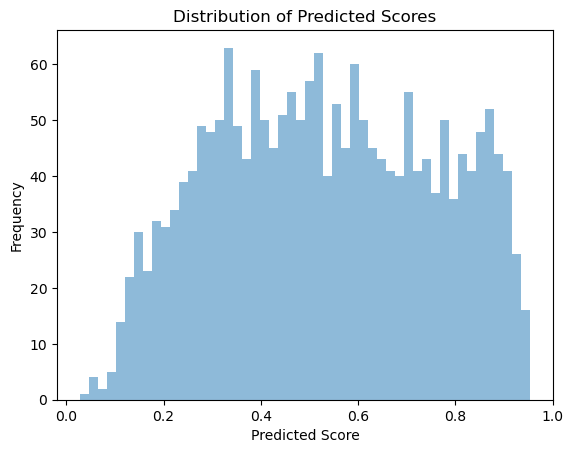

In [57]:
scores = model.predict_proba(X_test_encoded)[:, 1]
plt.hist(scores, bins=50, alpha=0.5, label='Predicted Scores')
plt.xlabel('Predicted Score')
plt.ylabel('Frequency')
plt.title('Distribution of Predicted Scores')
plt.show()

/work/giovani.valdrighi/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


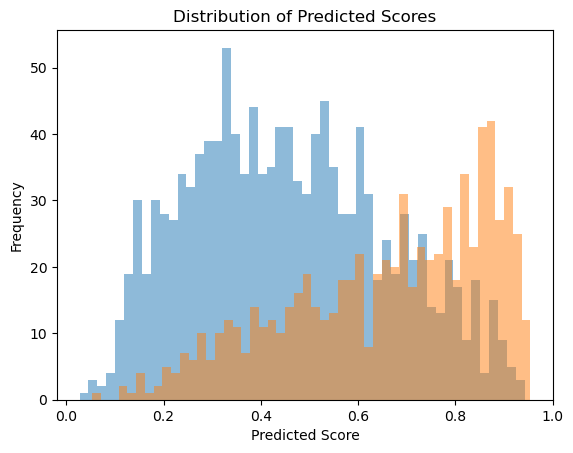

In [58]:
scores = model.predict_proba(X_test_encoded)[:, 1]
for i in range(2):
    plt.hist(scores[Z == i], bins=50, alpha=0.5, label=f'Group {i} Scores')
plt.xlabel('Predicted Score')
plt.ylabel('Frequency')
plt.title('Distribution of Predicted Scores')
plt.show()

In [59]:
X_encoded = np.concatenate([X_train_encoded, X_test_encoded], axis=0)
Y_pred = model.predict_proba(X_encoded)[:, 1]
pool = {
    "features" : X_encoded[:, 1:].astype(np.float32), # exclude the first column, the sensitive group
    "probs" : Y_pred.astype(np.float32),
    "group" : X_encoded[:, 0].astype(np.float32),
    "available" : [True] * X_encoded.shape[0],  # all applicants are available
}
with open("data/enem_pool.pkl", "wb") as f:
    pkl.dump(pool, f)

with open("data/enem_model.pkl", "wb") as f:
    pkl.dump(model, f)

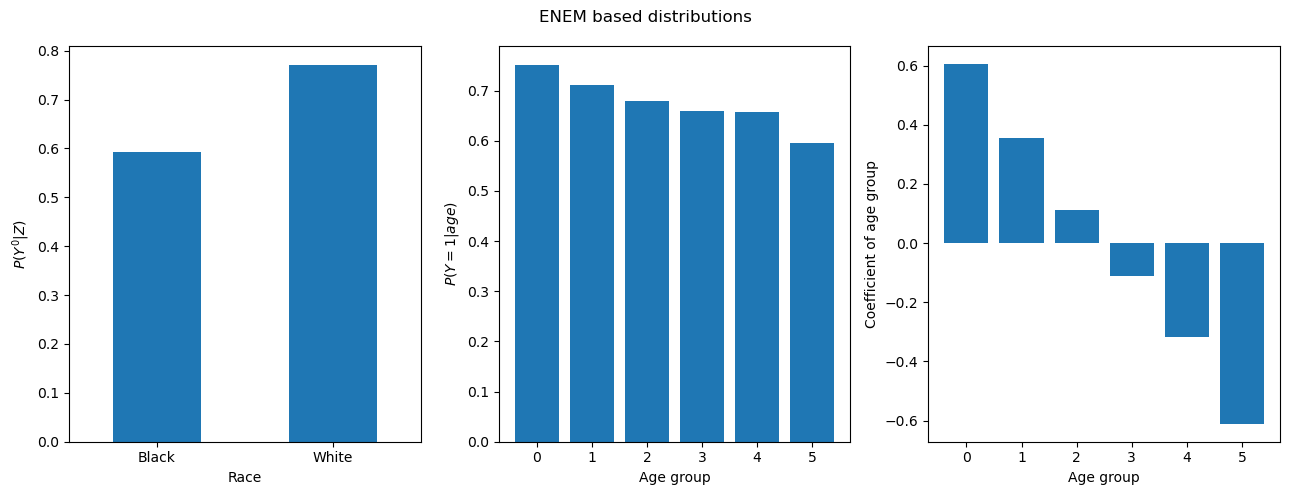

In [60]:
# bar plot of target grouped by "TP_COR_RACA"

fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (13, 5))
df.groupby("TP_COR_RACA")["target"].mean().plot(
    kind = "bar",
    ax = axs[0],
)

axs[0].set_ylabel("$P(Y^0|Z)$")
axs[0].set_xlabel("Race")
axs[0].set_xticklabels(["Black", "White"], rotation=0)


height_values = []
for i in sorted(df["TP_FAIXA_ETARIA"].unique()):
    height_values.append(df[df["TP_FAIXA_ETARIA"] == i]["target"].mean())

axs[1].bar(
    list(range(len(height_values))),
    height_values,
)

axs[1].set_xlabel("Age group")
axs[1].set_ylabel("$P(Y= 1|age)$")


age_coefs = model.coef_[0, 1:7]

axs[2].bar(
    list(range(len(age_coefs))),
    age_coefs,
)
axs[2].set_xlabel("Age group")
axs[2].set_ylabel("Coefficient of age group")



plt.suptitle("ENEM based distributions")
plt.tight_layout()
plt.savefig("enem1.pdf", bbox_inches='tight')
plt.show()